In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784')

In [2]:
mnist.data.shape

(70000, 784)

In [3]:
def showimage(dframe, index):
    some_digit = dframe.to_numpy()[index]
    some_digit_image = some_digit.reshape(28,28)

    plt.imshow(some_digit_image,cmap="binary")
    plt.axis("off")
    plt.show()

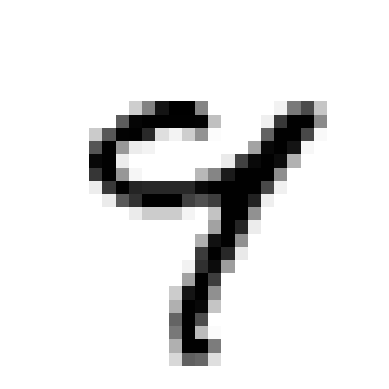

In [4]:
showimage(mnist.data, 54)

In [5]:
train_img, test_img, train_lbl, test_lbl = train_test_split(mnist.data, mnist.target, test_size=1/7.0, random_state=0)

In [6]:
type(train_img)

pandas.core.frame.DataFrame

In [7]:
test_img_copy = test_img.copy()

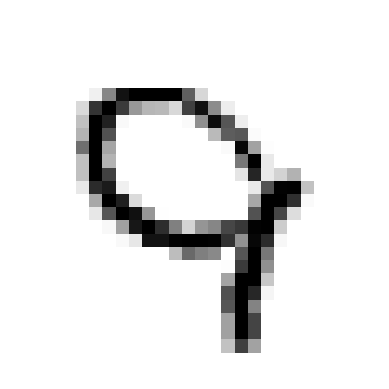

In [8]:
showimage(test_img_copy,5)

In [9]:
scaler = StandardScaler()

#scalerı sadece training set üzerinde fit yapmamız yeterli
scaler.fit(train_img)

#ama transform işlemini hem training sete hemde test sete yapmamız gerekiyor
train_img = scaler.transform(train_img)
test_img = scaler.transform(test_img)

In [10]:
pca = PCA(.95)

In [11]:
pca.fit(train_img)

PCA(n_components=0.95)

In [12]:
#bakalım 784 boyutu kaç boyuta düşürebilmiş(%95 variance'ı koruyarak tabiki)
print(pca.n_components_)

327


In [13]:
#şimdide transform işlemiyle hem train hem de test veri setimizin boyutlarını 784'ten 327'e düşürelim 
train_img = pca.transform(train_img)
test_img = pca.transform(test_img)

**2.AŞAMA**
Şimdi 2. makine öğrenmesi modelimiz olan Logistic Regression modelimizi PCA işleminden geçirilmiş veri setimiz üzerinde uygulayacağız.

In [14]:
#default solver çok yavaş çalıştığı için daha hızlı olan 'lbfgs' solverı seçerek logisticRegression nesnemizi oluşturuyoruz.
from sklearn.linear_model import LogisticRegression
logisticRegr = LogisticRegression(solver = 'lbfgs', max_iter=10000)

**Logistic Regression modelimizi train datamızı kullanarak eğitiyoruz:**

In [15]:
#(Birkaç dk sürebilir)
logisticRegr.fit(train_img, train_lbl)

LogisticRegression(max_iter=10000)

**Modelimiz eğitildi şimdi el yazısı rakamları makine öğrenmesi ile tanıma işlemini gerçekleştirelim:**

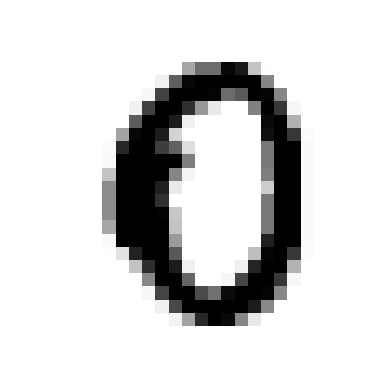

In [17]:
showimage(test_img_copy, 0)

In [18]:
logisticRegr.predict(test_img[0].reshape(1,-1))

array(['0'], dtype=object)

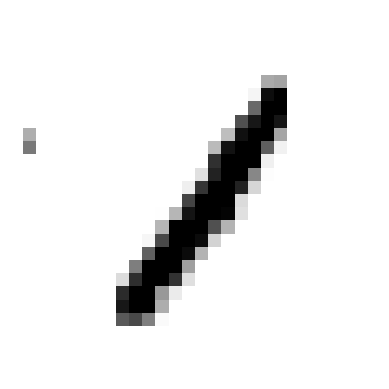

In [19]:
showimage(test_img_copy, 33)

In [21]:
logisticRegr.predict(test_img[33].reshape(1,-1))

array(['2'], dtype=object)

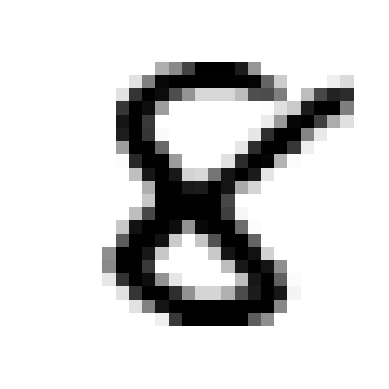

In [22]:
showimage(test_img_copy, 8784)

In [23]:
logisticRegr.predict(test_img[8784].reshape(1,-1))

array(['8'], dtype=object)

**Modelimizin doğruluk oranı(Accuracy) ölçmek**

In [24]:
#Modelimizin doğruluk oranı(Accuracy) ölçmek için score metodunu kullanacağız:
logisticRegr.score(test_img,test_lbl)

0.9185